# Week12 Lab —  Q-Learning with FrozenLake

Let's use Q-learning to train an agent to play FrozenLake

You can check the documentation for FrozenLake here:  
https://gymnasium.farama.org/environments/toy_text/frozen_lake/


## 1. Install and Import Libraries

We need:

- `gymnasium`: provides the FrozenLake environment.
- `numpy`: stores and updates the Q-table.
- `matplotlib`: plots training results.

If Gymnasium is not installed, run:

```python
!pip install gymnasium
```


In [92]:
# If needed, uncomment the following line:
# !pip install gymnasium

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt



## 2. Load FrozenLake Environment

FrozenLake is a small gridworld environment. The agent starts at **S** and wants to reach **G**.

A typical 4×4 map looks like this:

```text
S F F F
F H F H
F F F H
H F F G
```
Meaning:
- `S`: start
- `F`: frozen safe tile
- `H`: hole, bad terminal state
- `G`: goal, successful terminal state

We use:
```python
is_slippery=False
```
This makes the environment deterministic. If the agent chooses right, it really moves right.  

Later, you can set `is_slippery=True` to show stochastic transitions,meaning the agent’s movement is uncertain.


In [93]:
env = gym.make("FrozenLake-v1", is_slippery=False)

num_states = env.observation_space.n
num_actions = env.action_space.n

# Action names for readability.
action_names = {
    0: "Left",
    1: "Down",
    2: "Right",
    3: "Up"
}

possible_actions = [np.arange(num_actions) for state in range(num_states)]

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
for action_id, action_name in action_names.items():
    print(action_id, "=", action_name)


Observation space: Discrete(16)
Action space: Discrete(4)
0 = Left
1 = Down
2 = Right
3 = Up


## 3. Set Hyperparameters

1. Initial Learning Rate `alpha0`
```python
alpha0 = 0.05
```

2. Discount Factor `gamma`
Controls how much the agent cares about future rewards.
- \(\gamma=0\): only care about immediate reward.
- \(\gamma\approx1\): care strongly about future reward.

3. Initial State `state`
The training loop starts from:
```python
state = 0
```
which is the start cell.

Optional: Learning Rate Decay `decay`
The learning rate becomes smaller over time:
$$\alpha = \frac{\alpha_0}{1 + iteration \times decay}$$
This means the agent learns more aggressively early, then makes smaller updates later.


In [94]:
# Number of training episodes.
num_iterations = 5000

# Learning rate: how strongly we update the Q-table.
alpha0 = 0.2      

# Discount factor: how much the agent cares about future rewards.
gamma = 0.95      # discount factor

epsilon = 0.5     # initial exploration rate

print("maximum episode steps:", env.spec.max_episode_steps) 


maximum episode steps: 100


## 4. The Q-Learning Update Formula

Each time the agent takes one step, it observes:

```text
state, action, reward, next_state
```
And then, update Q(s,a):

$$Target = r+\gamma\max_{a'}Q(s',a')$$

$$Q(s,a) \leftarrow Q(s,a)+\alpha\left[Target-Q(s,a)\right]$$



Where:
- $Q(s,a)$: old estimate
- $r$: immediate reward
- $s'$: next state
- $max_{a'}Q(s',a')$: best estimated future value from the next state
- $alpha$: learning rate
- $gamma$: discount factor




In [95]:
def update_Q_values(Q_values, state, action, reward, next_state, alpha, gamma):
    next_value = np.max(Q_values[next_state])

    Target =  reward + gamma * next_value
    Q_values[state, action] = Q_values[state, action] - alpha * (Q_values[state, action]-Target) 

    return Q_values

## 5. Train the Agent

1. At the beginning, the agent knows nothing. So we initialize every Q-value to 0. 
    ```python
    Q = np.zeros([env.observation_space.n, env.action_space.n])
    ```

2.  The exploratory behavior policy is that the agent randomly chooses one possible action during training
    ```python
    def exploration_policy(state):
        return np.random.choice(possible_actions[state])
    ```
As we set Epsilon to control exploration, the agent will chooses a random action 10% of the time; and chooses the action with the highest Q-value 90% of the time.

3. when taking a new step, we can get reward or next_sate by call function: 

    ```next_state, reward, terminated, truncated, info = env.step(action)```
    1. terminated = True (state = Hole or state = Goal) 
    2. truncated means the episode was stopped by an outside limit


4. For FrozenLake, an episode ends when the agent reaches a hole or the goal. When this happens, we reset back to the start state so training can continue.
We also record:
- return per episode
- steps per episode


   


In [96]:
# Initialize Q-table before training
Q_values = np.zeros((env.observation_space.n, env.action_space.n))

episode_returns = [] # Store total reward for each episode.
episode_steps = []   # Store number of steps for each episode.
success_rate = []# Store success indicator for each episode.


# Run the Q-learning algorithm.
for iteration in range(num_iterations):
    # Reset the environment at the beginning of each episode.
    state,info = env.reset()
    # done tells us whether the episode has ended.
    done = False
    # Total reward collected in this episode.
    episode_return = 0
    # Number of steps used in this episode. 
    episode_step = 0
    
    
#   while not done and episode_step < max_steps_per_episode:
    for step in range(env.spec.max_episode_steps): #100 by default
       
        # 1. Choose action with Epsilon-greedy action selection
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(Q_values[state]))

        # 2. Take one step and observe next state, reward, and done.
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        if terminated:
            target = reward
        else:
            target = reward + gamma * np.max(Q_values[next_state])
        
        # 3. Update Q-table, using the textbook-style update
        Q_values = update_Q_values(Q_values, state, action, reward, next_state, alpha0, gamma)
        state = next_state

        # 5. Track episode metrics
        episode_return += reward
        episode_step += 1
    
        # If the episode ended, reset to the start state for the next episode.
        if done:
            episode_returns.append(episode_return)
            episode_steps.append(episode_step)
            success_rate.append(int(episode_return > 0))
            break
        
    # Print progress every 1000 episodes.
    if (iteration + 1) % 1000 == 0:
        recent_success = np.mean(success_rate[-1000:]) * 100
        print("Episode:", iteration + 1,
              "| Reward:", episode_return,
              "| Steps:", episode_step,
              "| Recent success rate:", f"{recent_success:.1f}%")

print("Training finished.")
print("Number of completed episodes:", len(episode_returns))

Episode: 1000 | Reward: 1 | Steps: 20 | Recent success rate: 32.8%
Episode: 2000 | Reward: 1 | Steps: 7 | Recent success rate: 42.2%
Episode: 3000 | Reward: 0 | Steps: 7 | Recent success rate: 42.1%
Episode: 4000 | Reward: 1 | Steps: 6 | Recent success rate: 42.3%
Episode: 5000 | Reward: 1 | Steps: 7 | Recent success rate: 39.8%
Training finished.
Number of completed episodes: 5000



## 9. Inspect the Learned Q-Table

After training, the Q-table contains learned estimates of long-term action values.

Each row is one state.  
Each column is one action.

For each state, the best action is:

\[
\arg\max_a Q(s,a)
\]


In [97]:
np.set_printoptions(precision=3, suppress=True)

print("Learned Q-table:")
print(Q_values)

best_actions = np.argmax(Q_values, axis=1)

print("\nBest action for each state:")
print(best_actions)

print("\nBest actions reshaped as 4x4 grid:")
print(best_actions.reshape(4, 4))

best_action_names = np.array([action_names[a] for a in best_actions]).reshape(4, 4)
print(best_action_names.reshape(4, 4))

Learned Q-table:
[[0.735 0.774 0.774 0.735]
 [0.735 0.    0.815 0.774]
 [0.774 0.857 0.774 0.815]
 [0.815 0.    0.765 0.762]
 [0.774 0.815 0.    0.735]
 [0.    0.    0.    0.   ]
 [0.    0.902 0.    0.815]
 [0.    0.    0.    0.   ]
 [0.815 0.    0.857 0.774]
 [0.815 0.902 0.902 0.   ]
 [0.857 0.95  0.    0.857]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.902 0.95  0.857]
 [0.902 0.95  1.    0.902]
 [0.    0.    0.    0.   ]]

Best action for each state:
[1 2 1 0 1 0 1 0 2 1 1 0 0 2 2 0]

Best actions reshaped as 4x4 grid:
[[1 2 1 0]
 [1 0 1 0]
 [2 1 1 0]
 [0 2 2 0]]
[['Down' 'Right' 'Down' 'Left']
 ['Down' 'Left' 'Down' 'Left']
 ['Right' 'Down' 'Down' 'Left']
 ['Left' 'Right' 'Right' 'Left']]



## 11. Plot Return per Episode

In FrozenLake, the reward is usually:

- `1` if the agent reaches the goal
- `0` otherwise

So return per episode is often 0 or 1.

If the curve improves over time, it means the agent is reaching the goal more often.


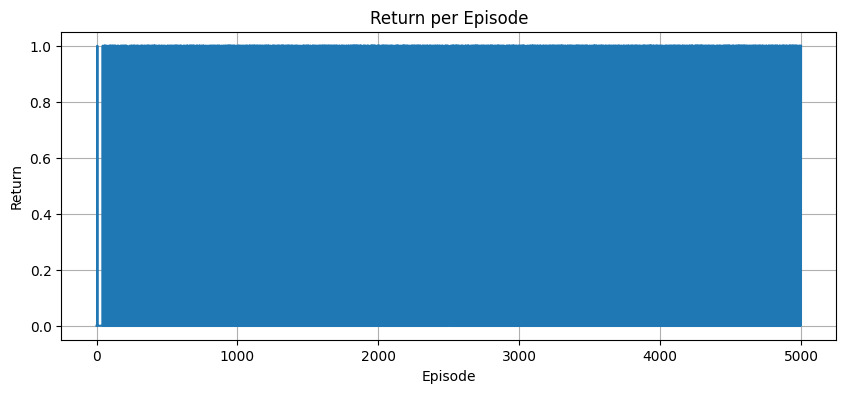

In [98]:

plt.figure(figsize=(10, 4))
plt.plot(episode_returns)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Return per Episode")
plt.grid(True)
plt.show()



## 12. Plot Moving Average Return

Raw episode returns can be noisy.

A moving average makes the trend easier to see.


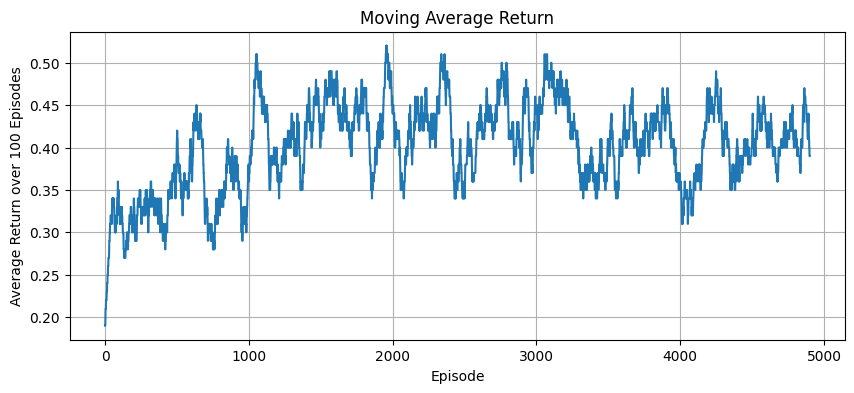

In [105]:

def moving_average(data, window_size=100):
    return np.convolve(data, np.ones(window_size) / window_size, mode="valid")

window_size = 100
avg_returns = moving_average(episode_returns, window_size)

plt.figure(figsize=(10, 4))
plt.plot(avg_returns)
plt.xlabel("Episode")
plt.ylabel(f"Average Return over {window_size} Episodes")
plt.title("Moving Average Return")
plt.grid(True)
plt.show()



## 13. Plot Steps per Episode

Steps per episode tells us how long the agent takes before the episode ends.

In FrozenLake:

- Falling into a hole ends the episode.
- Reaching the goal ends the episode.

So steps alone should be interpreted together with return.


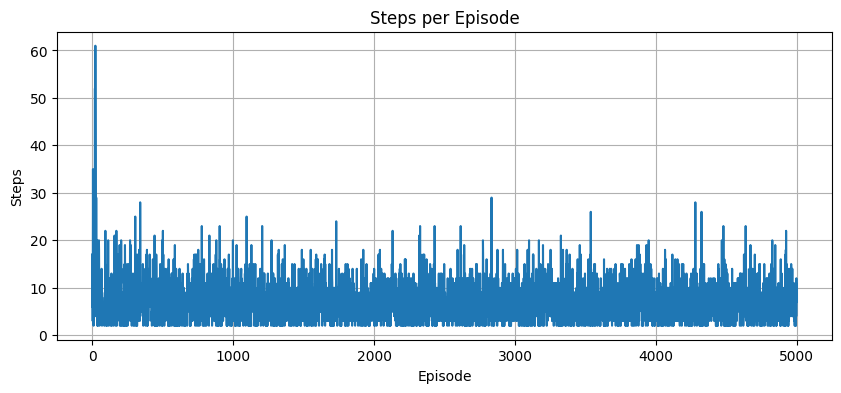

In [100]:

plt.figure(figsize=(10, 4))
plt.plot(episode_steps)
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.title("Steps per Episode")
plt.grid(True)
plt.show()


## 14. Test the Learned Policy

Now we use the learned Q-table without exploration.

That means:

```python
action = np.argmax(Q_values[state])
```

This is the greedy policy derived from the Q-table.

In [101]:
def run_one_episode(env, Q_values, seed=42, max_steps=100):
    state, info = env.reset(seed=seed)
    done = False
    total_reward = 0
    steps = 0
    path = [state]

    while not done and steps < max_steps:
        action = np.argmax(Q_values[state])
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        total_reward += reward
        steps += 1
        state = next_state
        path.append(state)

    return total_reward, steps, path


test_return, test_steps, test_path = run_one_episode(env, Q_values)

print("Test return:", test_return)
print("Test steps:", test_steps)
print("Path:", test_path)
print("Path as grid positions:", [(s // 4, s % 4) for s in test_path])

Test return: 1
Test steps: 6
Path: [0, 4, 8, 9, 13, 14, 15]
Path as grid positions: [(0, 0), (1, 0), (2, 0), (2, 1), (3, 1), (3, 2), (3, 3)]


## 15. Generate Episode Data

After training, we can run one full episode using the learned `Q_values` table and record every transition.

This gives us two useful tables:

- `states_df`: every visited state in the episode
- `transitions_df`: each movement from one state to the next state

The policy below is greedy by default, so it uses:

\[
a = \arg\max_a Q(s,a)
\]

You can set `epsilon > 0` if you want to show exploratory behavior.

In [102]:
import pandas as pd


def state_to_row_col(state, ncol):
    """Convert a FrozenLake state id to row and column numbers.

    The returned row and column are 1-based, which is easier for classroom display.
    """
    row = int(state // ncol) + 1
    col = int(state % ncol) + 1
    return row, col


def generate_episode_data(env, Q_values, epsilon=0.0, seed=42, max_steps=100):
    """Generate one episode and store the trajectory as data tables."""
    desc = env.unwrapped.desc.astype(str)
    nrow, ncol = desc.shape

    state, info = env.reset(seed=seed)
    done = False

    states_data = []
    transitions_data = []

    row, col = state_to_row_col(state, ncol)
    states_data.append({
        "t": 0,
        "state": int(state),
        "row": row,
        "col": col,
        "tile": desc[row - 1, col - 1],
        "reward": 0.0
    })

    for t in range(1, max_steps + 1):
        if done:
            break

        from_state = state
        from_row, from_col = state_to_row_col(from_state, ncol)

        # Greedy policy by default. Use epsilon > 0 to add exploration.
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(Q_values[state]))

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        to_row, to_col = state_to_row_col(next_state, ncol)

        transitions_data.append({
            "t": t,
            "from_state": int(from_state),
            "to_state": int(next_state),
            "from_row": from_row,
            "from_col": from_col,
            "to_row": to_row,
            "to_col": to_col,
            "action": int(action),
            "action_name": action_names.get(int(action), str(action)),
            "reward": float(reward),
            "done": bool(done)
        })

        states_data.append({
            "t": t,
            "state": int(next_state),
            "row": to_row,
            "col": to_col,
            "tile": desc[to_row - 1, to_col - 1],
            "reward": float(reward)
        })

        state = next_state

    states_df = pd.DataFrame(states_data)
    transitions_df = pd.DataFrame(transitions_data)

    return states_df, transitions_df


states_df, transitions_df = generate_episode_data(
    env,
    Q_values,
    epsilon=0.0,   # greedy policy after training
    seed=42,
    max_steps=100
)

print("Visited states:")
display(states_df)

print("\nTransitions:")
display(transitions_df)

Visited states:


,t,state,row,col,tile,reward
0,0,0,1,1,S,0.0
1,1,4,2,1,F,0.0
2,2,8,3,1,F,0.0
3,3,9,3,2,F,0.0
4,4,13,4,2,F,0.0
5,5,14,4,3,F,0.0
6,6,15,4,4,G,1.0



Transitions:


,t,from_state,to_state,from_row,from_col,to_row,to_col,action,action_name,reward,done
0,1,0,4,1,1,2,1,1,Down,0.0,False
1,2,4,8,2,1,3,1,1,Down,0.0,False
2,3,8,9,3,1,3,2,2,Right,0.0,False
3,4,9,13,3,2,4,2,1,Down,0.0,False
4,5,13,14,4,2,4,3,2,Right,0.0,False
5,6,14,15,4,3,4,4,2,Right,1.0,True



## 16. Plot the Generated Episode

The yellow cells show the visited path.

The green arrows show the movements made by the agent during the generated episode.

Blue cells are holes, and the green cell is the goal.


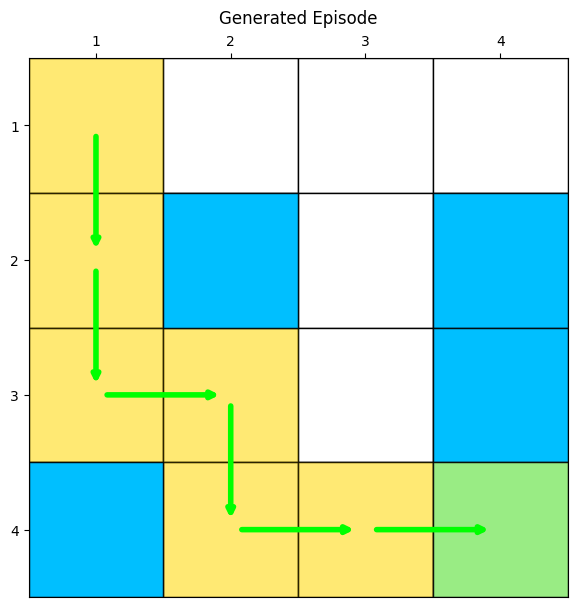

In [103]:

from matplotlib.patches import Rectangle


def plot_generated_episode(env, states_df, transitions_df, title="Generated Episode"):
    """Plot one generated FrozenLake episode on the grid."""
    desc = env.unwrapped.desc.astype(str)
    nrow, ncol = desc.shape

    fig, ax = plt.subplots(figsize=(7, 7))

    # 1. Draw base map
    for r in range(nrow):
        for c in range(ncol):
            tile = desc[r, c]

            if tile == "H":
                facecolor = "deepskyblue"     # hole
            elif tile == "G":
                facecolor = "lightgreen"      # goal
            else:
                facecolor = "white"           # start or frozen tile

            ax.add_patch(
                Rectangle(
                    (c, r),
                    1,
                    1,
                    facecolor=facecolor,
                    edgecolor="black",
                    linewidth=1
                )
            )

    # 2. Highlight visited cells
    for _, row in states_df.iterrows():
        r = int(row["row"]) - 1
        c = int(row["col"]) - 1

        ax.add_patch(
            Rectangle(
                (c, r),
                1,
                1,
                facecolor="gold",
                alpha=0.55,
                edgecolor="black",
                linewidth=1
            )
        )

    # 3. Re-draw terminal cells on top, so holes and goal remain clear
    for r in range(nrow):
        for c in range(ncol):
            tile = desc[r, c]
            if tile == "H":
                ax.add_patch(
                    Rectangle((c, r), 1, 1, facecolor="deepskyblue", alpha=0.85,
                              edgecolor="black", linewidth=1)
                )
            elif tile == "G":
                ax.add_patch(
                    Rectangle((c, r), 1, 1, facecolor="lightgreen", alpha=0.85,
                              edgecolor="black", linewidth=1)
                )

    # 4. Draw movement arrows
    for _, row in transitions_df.iterrows():
        x1 = float(row["from_col"]) - 0.5
        y1 = float(row["from_row"]) - 0.5
        x2 = float(row["to_col"]) - 0.5
        y2 = float(row["to_row"]) - 0.5

        # If the agent hits a wall, the state may not change. Mark it as a dot.
        if x1 == x2 and y1 == y2:
            ax.plot(x1, y1, marker="o", markersize=9, color="lime")
            continue

        ax.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(
                arrowstyle="->",
                linewidth=4,
                color="lime",
                shrinkA=8,
                shrinkB=8
            )
        )

    # 5. Add grid labels like the teaching figure
    ax.set_xticks(np.arange(ncol) + 0.5)
    ax.set_yticks(np.arange(nrow) + 0.5)
    ax.set_xticklabels(np.arange(1, ncol + 1))
    ax.set_yticklabels(np.arange(1, nrow + 1))
    ax.xaxis.tick_top()

    ax.set_xlim(0, ncol)
    ax.set_ylim(nrow, 0)
    ax.set_aspect("equal")
    ax.set_title(title, pad=25)
    ax.grid(False)

    plt.show()


plot_generated_episode(env, states_df, transitions_df)



## 17. Optional: Render the Environment

Rendering may work differently depending on where you run the notebook.

For a simple classroom notebook, the path printed above is usually enough.

If you want to render each step visually, create the environment with:

```python
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="human")
```

Then run one episode.

This works better on a local machine than in some cloud notebook environments.


In [104]:
# Optional local rendering example:
# env_render = gym.make("FrozenLake-v1", is_slippery=False, render_mode="human")
# state, info = env_render.reset()
# done = False
#
# while not done:
#     action = np.argmax(Q_values[state])
#     next_state, reward, terminated, truncated, info = env_render.step(action)
#     done = terminated or truncated
#     state = next_state
#
# env_render.close()

## 18. Connection to the Assignment

This lab uses FrozenLake, but the assignment uses a larger discrete environment.

The structure is the same:

```text
state
action
reward
next_state
Q-table
exploration policy
Q-learning update
episodes
return per episode
steps per episode
```

The main difference is the size of the Q-table.

For FrozenLake:

```python
Q_values = np.zeros((16, 4))
```

For a larger discrete environment, use:

```python
Q_values = np.zeros((number_of_states, number_of_actions))
```

The Q-learning update is the same.


## 19. Discussion Questions

1. Why do we need future reward instead of only immediate reward?
2. What happens if \(\epsilon\) is too high?
3. What happens if \(\epsilon\) is too low?
4. What happens if \(\gamma=0\)?
5. Why does Q-table work for FrozenLake?
6. Why might Q-table fail for image-based games such as Atari or Mario?
7. How is Q-learning different from simply following the highest immediate reward?



## 20. Optional Extension: Slippery FrozenLake

Try changing:

```python
is_slippery=False
```

to:

```python
is_slippery=True
```

Now the environment becomes stochastic. The action may not always move the agent in the intended direction.

Discussion:

- Does training become harder?
- Do you need more episodes?
- Does the learned policy change?
